To-Do-1: Data Understanding, Analysis & Preparation

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [25]:

data = pd.read_csv("/content/drive/MyDrive/Concept and technology of AI/Houseprice.csv")

data.head()


,HouseAge,HouseFloor,HouseArea,HousePrice
0,52,2,112.945574,543917.179841
1,93,1,174.312126,817740.124828
2,15,4,125.219577,387992.503019
3,72,4,121.210124,240840.742388
4,61,4,59.221737,277273.386525


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
data.tail()

,HouseAge,HouseFloor,HouseArea,HousePrice
95,85,1,120.193091,540347.535683
96,80,1,56.078992,222539.252789
97,82,2,211.368074,715211.774907
98,53,4,94.277670,210926.069798
99,24,4,285.114646,988329.950912


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HouseAge    100 non-null    int64  
 1   HouseFloor  100 non-null    int64  
 2   HouseArea   100 non-null    float64
 3   HousePrice  100 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [44]:
data.isnull().sum()

,0
HouseAge,0
HouseFloor,0
HouseArea,0
HousePrice,0


In [29]:
data.describe()

,HouseAge,HouseFloor,HouseArea,HousePrice
count,100.000000,100.000000,100.000000,1.000000e+02
mean,51.540000,2.910000,170.226332,5.790964e+05
std,29.425963,1.457097,71.298821,2.615097e+05
min,2.000000,1.000000,51.265396,1.493562e+05
25%,23.500000,1.000000,109.770201,3.905859e+05
50%,54.000000,3.000000,176.846510,5.391941e+05
75%,76.500000,4.000000,222.794276,7.479899e+05
max,100.000000,5.000000,296.412614,1.228712e+06


To-Do-2: Create Matrices (No Bias Term)

In [31]:
X = data[['HouseAge', 'HouseFloor', 'HouseArea']].values
Y = data['HousePrice'].values

In [32]:
X_matrix = X.T
Y_matrix = Y

To-Do-3: Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

To-Do-4: Cost Function (Mean Squared Error)

In [34]:
def cost_function(X, Y, W):
    """ Parameters:
    This function finds the Mean Square Error.
    Input parameters:
      X: Feature Matrix
      Y: Target Matrix
      W: Weight Matrix
    Output Parameters:
      J: accumulated mean square error.
    """
    n = len(Y)
    Y_pred = np.dot(X, W)
    cost = (1 / (2 * n)) * np.sum((Y_pred - Y) ** 2)
    return cost


To-Do-5: Cost Function Test Case

In [35]:
X_test_case = np.array([[1, 2],
                        [3, 4],
                        [5, 6]])
Y_test_case = np.array([3, 7, 11])
W_test_case = np.array([1, 1])

cost = cost_function(X_test_case, Y_test_case, W_test_case)

if cost == 0:
    print("Proceed")
else:
    print("Something went wrong")

print("Cost function output:", cost)


Proceed Further
Cost function output: 0.0


To-Do-6: Gradient Descent Implementation

In [36]:
def gradient_descent(X, Y, W, alpha, iterations):
    cost_history = [0] * iterations
    m = len(Y)

    for i in range(iterations):
        # Prediction
        Y_pred = np.dot(X, W)

        # Error
        loss = Y_pred - Y

        # Gradient
        dw = (1 / m) * np.dot(X.T, loss)

        # Update weights
        W = W - alpha * dw

        # Cost
        cost_history[i] = cost_function(X, Y, W)

    return W, cost_history

To-Do-7: Gradient Descent Test Case

In [53]:
np.random.seed(0)

X = np.random.rand(100, 3)
Y = np.random.rand(100)
W = np.random.rand(3)

alpha = 0.01
iterations = 1000

final_params, cost_history = gradient_descent(X, Y, W, alpha, iterations)

print("Final Parameters:", final_params)
print("Cost History (Last 5):", cost_history[-5:])

Final Parameters: [0.20551667 0.54295081 0.10388027]
Cost History (Last 5): [np.float64(0.05436764093665037), np.float64(0.054364452919908414), np.float64(0.05436127052403898), np.float64(0.05435809373901896), np.float64(0.05435492255484332)]


To-Do-8: RMSE Implementation

In [55]:
def rmse(Y, Y_pred):
    return np.sqrt(np.mean((Y - Y_pred) ** 2))


To-Do-9: R-Squared Implementation

In [51]:
def r2(Y, Y_pred):
    mean_y = np.mean(Y)
    ss_tot = np.sum((Y - mean_y) ** 2)
    ss_res = np.sum((Y - Y_pred) ** 2)
    return 1 - (ss_res / ss_tot)


To-Do-10: Main Function (Full Pipeline)

In [72]:
def main():
    # Load dataset
    data = pd.read_csv("/content/drive/MyDrive/Concept and technology of AI/Houseprice.csv")

    # Features & target
    X = data[['HouseAge', 'HouseFloor', 'HouseArea']].values
    Y = data['HousePrice'].values

    # Train-test split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    # Initialize weights and hyperparameters
    W = np.zeros(X_train.shape[1])
    alpha = 0.0000001
    iterations = 2000

    # Train model
    W_optimal, cost_history = gradient_descent(
        X_train, Y_train, W, alpha, iterations
    )

    # Predictions
    Y_pred = np.dot(X_test, W_optimal)

    # Evaluation
    model_rmse = rmse(Y_test, Y_pred)
    model_r2 = r2(Y_test, Y_pred)

    # Output
    print("Final Weights:", W_optimal)
    print("-----------------------------------------------")
    print("Cost History (First 5):", cost_history[:5])
    print("-----------------------------------------------")
    print("RMSE on Test Set:", model_rmse)
    print("-----------------------------------------------")
    print("R² Score on Test Set:", model_r2)


In [73]:
if __name__ == "__main__":
    main()


Final Weights: [ 656.92199554   41.51859888 3189.90342055]
-----------------------------------------------
Cost History (First 5): [np.float64(203427198795.5448), np.float64(202037228070.84967), np.float64(200657348546.91064), np.float64(199287486958.6209), np.float64(197927570572.8009)]
-----------------------------------------------
RMSE on Test Set: 162373.58690327898
-----------------------------------------------
R² Score on Test Set: 0.351986093783084


11. Evaluation Metrics
RMSE

In [74]:
def rmse(Y, Y_pred):
    return np.sqrt(np.mean((Y - Y_pred) ** 2))

In [75]:
def r2(Y, Y_pred):
    mean_y = np.mean(Y)
    ss_tot = np.sum((Y - mean_y) ** 2)
    ss_res = np.sum((Y - Y_pred) ** 2)
    return 1 - (ss_res / ss_tot)

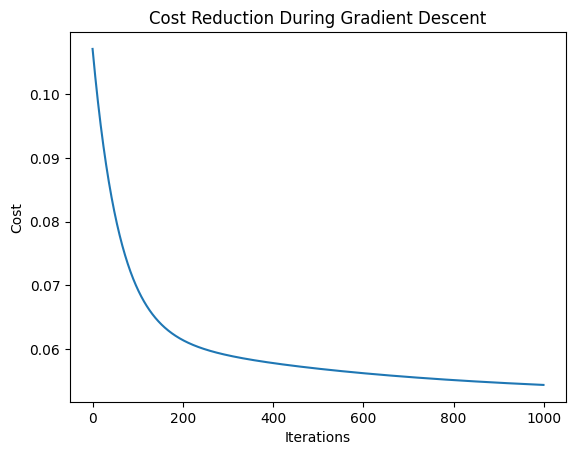

In [76]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction During Gradient Descent")
plt.show()